In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SQL_DIR = PROJECT_ROOT / "sql"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
os.chdir(PROJECT_ROOT)

plt.style.use("seaborn-v0_8-darkgrid")

con = duckdb.connect(str(DATA_DIR / "criteo.duckdb"))
print(f"Connected. Row count: {con.execute('SELECT COUNT(*) FROM criteo').fetchone()[0]:,}")

Connected. Row count: 13,979,592


In [2]:
features = [f"f{i}" for i in range(12)]

def feature_stats_block(feat: str) -> str:
    return f"""SELECT
    '{feat}' AS feature_name,
    MIN({feat})                             AS min_val,
    MAX({feat})                             AS max_val,
    AVG({feat})                             AS mean_val,
    STDDEV({feat})                          AS std_val,
    quantile_cont({feat}, 0.10)             AS p10,
    quantile_cont({feat}, 0.25)             AS p25,
    quantile_cont({feat}, 0.50)             AS p50,
    quantile_cont({feat}, 0.75)             AS p75,
    quantile_cont({feat}, 0.90)             AS p90,
    quantile_cont({feat}, 0.99)             AS p99
FROM criteo"""

header = """-- Auto-generated by notebooks/01_eda.ipynb (Day 3).
-- Per-feature summary statistics for f0..f11.
-- Run from project root: duckdb data/criteo.duckdb < sql/02_eda_features.sql

"""

sql_text = header + "\nUNION ALL\n".join(feature_stats_block(f) for f in features) + "\nORDER BY feature_name;\n"

sql_path = SQL_DIR / "02_eda_features.sql"
sql_path.write_text(sql_text)
print(f"Wrote {sql_path} ({len(sql_text):,} chars)")

Wrote /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/sql/02_eda_features.sql (6,826 chars)


In [3]:
%%time
summary_df = con.execute(sql_text).fetchdf()
summary_df

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CPU times: user 21.6 s, sys: 6.03 s, total: 27.6 s
Wall time: 13.9 s


,feature_name,min_val,max_val,mean_val,std_val,p10,p25,p50,p75,p90,p99
0,f0,12.616365,26.745255,19.620297,5.377464,12.616365,12.616365,21.923413,24.436459,25.990926,26.672876
1,f1,10.059654,16.344187,10.069977,0.104756,10.059654,10.059654,10.059654,10.059654,10.059654,10.679513
2,f10,5.300375,6.473917,5.333396,0.168229,5.300375,5.300375,5.300375,5.300375,5.300375,6.337266
3,f11,-1.383941,-0.168679,-0.170967,0.022833,-0.168679,-0.168679,-0.168679,-0.168679,-0.168679,-0.168679
4,f2,8.214383,9.051962,8.446582,0.299316,8.214383,8.214383,8.214383,8.723335,8.950724,9.042916
5,f3,-8.398387,4.679882,4.178923,1.336645,2.587543,4.679882,4.679882,4.679882,4.679882,4.679882
6,f4,10.280525,21.123508,10.338837,0.343308,10.280525,10.280525,10.280525,10.280525,10.280525,11.973287
7,f5,-9.011892,4.115453,4.028513,0.431097,4.115453,4.115453,4.115453,4.115453,4.115453,4.115453
8,f6,-31.429784,0.294443,-4.155356,4.577914,-10.987528,-6.699321,-2.411115,0.294443,0.294443,0.294443
9,f7,4.833815,11.998401,5.101765,1.205248,4.833815,4.833815,4.833815,4.833815,4.833815,11.482084


In [4]:
summary_df.to_csv(FIG_DIR / "feature_summary.csv", index=False)
print(f"Saved {FIG_DIR / 'feature_summary.csv'}")

Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/feature_summary.csv


In [5]:
%%time
sample_df = con.execute("SELECT * FROM criteo USING SAMPLE 500000 ROWS").fetchdf()
print(f"Sample shape: {sample_df.shape}")
print(f"Memory: {sample_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Sample shape: (500000, 16)
Memory: 64.0 MB
CPU times: user 1.18 s, sys: 408 ms, total: 1.59 s
Wall time: 1.33 s


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/feature_distributions.png


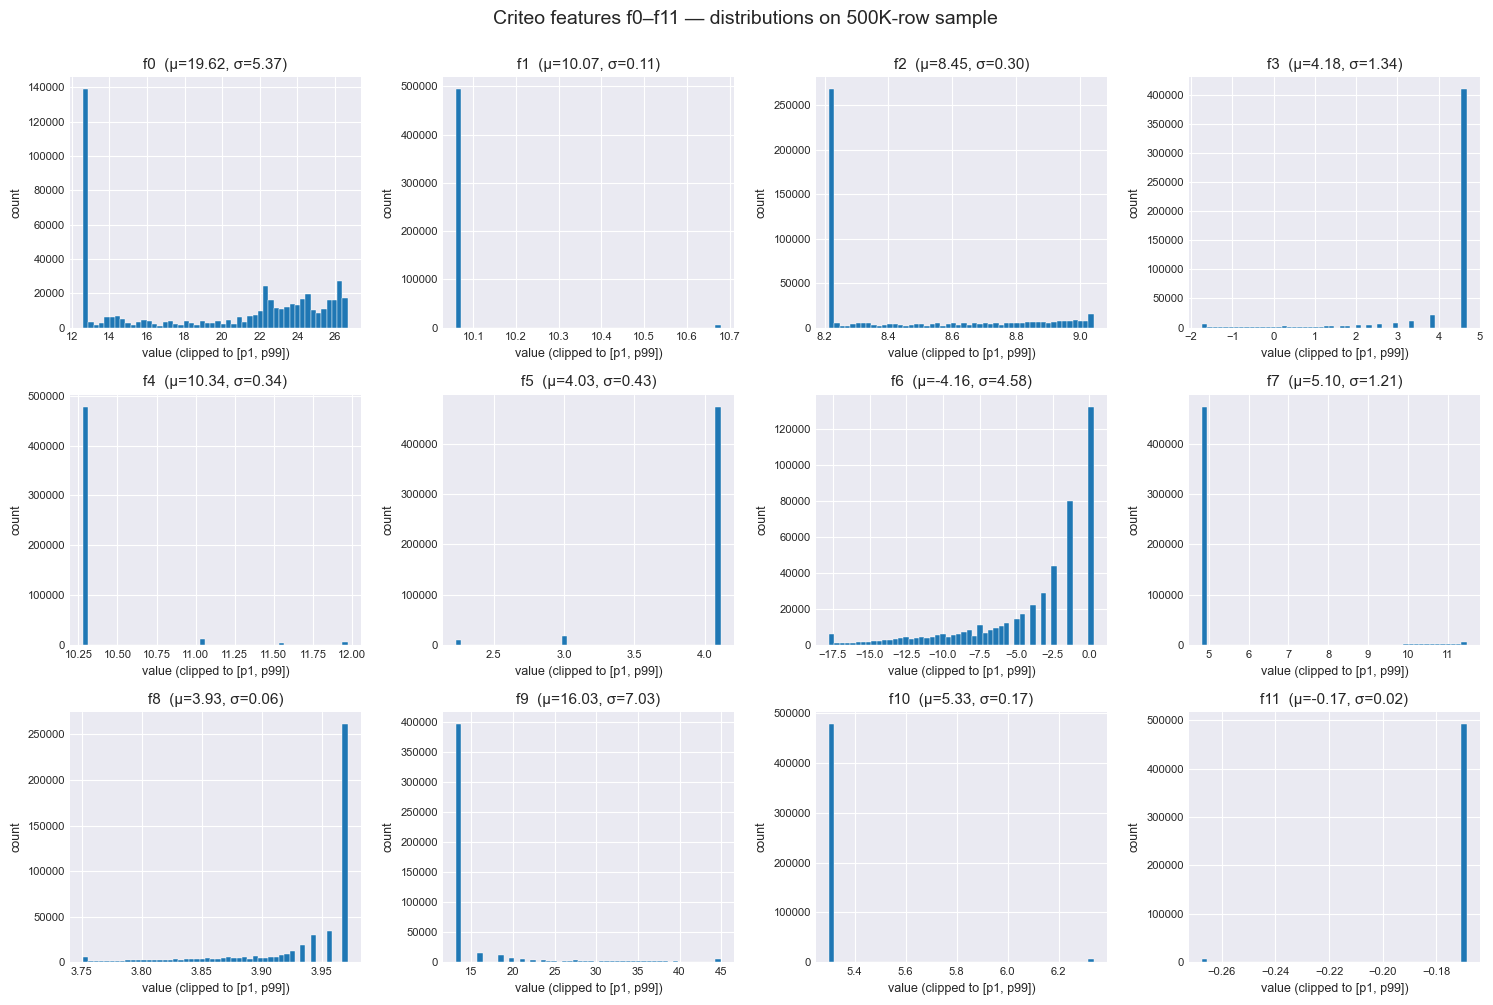

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    data = sample_df[feat]
    p1, p99 = np.percentile(data, [1, 99])
    clipped = data.clip(p1, p99)

    ax.hist(clipped, bins=50, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{feat}  (μ={data.mean():.2f}, σ={data.std():.2f})", fontsize=11)
    ax.set_xlabel("value (clipped to [p1, p99])", fontsize=9)
    ax.set_ylabel("count", fontsize=9)
    ax.tick_params(labelsize=8)

plt.suptitle("Criteo features f0–f11 — distributions on 500K-row sample", fontsize=14, y=1.00)
plt.tight_layout()

out_path = FIG_DIR / "feature_distributions.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()

In [7]:
inner_sql = sql_text.rstrip().rstrip(";")
diagnostics = con.execute(f"""
    SELECT
        feature_name,
        ROUND(p50, 3) AS median,
        ROUND(p99, 3) AS p99,
        ROUND(max_val, 3) AS max,
        ROUND( (p99 - p50) / NULLIF(p50, 0), 2) AS p99_to_median_ratio,
        ROUND( (max_val - p99) / NULLIF(p99 - p50, 0), 2) AS tail_severity
    FROM ({inner_sql}) sub
    ORDER BY tail_severity DESC NULLS LAST
""").fetchdf()
diagnostics

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,feature_name,median,p99,max,p99_to_median_ratio,tail_severity
0,f1,10.060,10.680,16.344,0.06,9.14
1,f4,10.281,11.973,21.124,0.16,5.41
2,f9,13.190,44.894,75.295,2.40,0.96
3,f10,5.300,6.337,6.474,0.20,0.13
4,f7,4.834,11.482,11.998,1.38,0.08
5,f0,21.923,26.673,26.745,0.22,0.02
6,f2,8.214,9.043,9.052,0.10,0.01
7,f6,-2.411,0.294,0.294,-1.12,0.00
8,f11,-0.169,-0.169,-0.169,-0.00,NaN
9,f3,4.680,4.680,4.680,0.00,NaN


In [8]:
con.close()
print("Connection closed.")

Connection closed.
